In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


In [2]:
from scipy.signal import find_peaks

def load_file_one_go(files, chunk_size, baseline_window_ns, channel):
    prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin='zero',
    )
    time_ns = prerocessed_data["time_ns"]
    voltage_mV = prerocessed_data["voltage_mV"]

    preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in ['is_saturated', 'n_saturated_samples']}
    preprocessed_event_info.update({ 
        'event_file': prerocessed_data['event_file'],
        'event_segment': prerocessed_data['event_segment']
    })

    df = build_waveform_feature_dataframe(
        time_ns,
        voltage_mV,
        peak_threshold_mV=None,
        second_peak_min_height_frac=0.2,
        pre_peak_ns = 20,
        post_peak_ns = 80,
        pre_rise_ns = 10, 
        post_rise_ns = 80, 
        extra=preprocessed_event_info 
    )
    cutflow = CutFlow(len(df))

    cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
    cutflow.print()

    df_sel = df[cutflow.mask].copy()
    waveforms_sel = voltage_mV[cutflow.mask]

    return [time_ns, waveforms_sel, df_sel]


In [3]:
# period / Fourier
def get_period_peak_to_peak(t_ns, waveforms, t_range, mask_events, verbose=True, prominence=None, distance=None):
    mask_time = (t_ns > t_range[0]) & (t_ns < t_range[1])
    t_window = t_ns[mask_time]
    mean_waveform = np.mean( waveforms[mask_events.values], axis=0 )
    v_window = mean_waveform[mask_time]

    peaks, _ = find_peaks(v_window, prominence=prominence, distance=distance)

    peak_times = t_window[peaks]
    periods = np.diff(peak_times)

    if verbose:
        print(f"Time window  : {t_window[0]:.3f} to {t_window[-1]:.3f} ns")
        print(f"N peaks      : {len(peaks)}")
        print(f"Mean period = {periods.mean():.3f} ns")
        print(f"Frequency   = {1/periods.mean():.3f} GHz")

    return periods.mean(), 1/periods.mean(), peak_times

# Configuration

In [4]:
chunk_size = 512 
baseline_window_width_ns = 20
basic_plots=True

baseline_window_ns = (0 ,baseline_window_width_ns)


# Select Files


In [5]:
channel = "Channel 4"
data_dir = 'data/WA0089/260702'

# save
save_plots = True
save_dir = 'plots_noise'
# file_nickname = '' 

# 1. LED 1

In [6]:


data = {}

led = '1'

for BW in ['525', '20']:
    for freq, kf in zip(['HIGH', 'LOW'], ['high', 'low']):
        key = f'led{led}_{kf}_{BW}'
        file_name = f"{data_dir}/led0{led}0_{freq}_850V_{BW}MHz-1.h5"
        if key=='led0_high_525':
            file_name = f"{data_dir}/led0{led}0_{freq}_850V_{BW}MHz-2.h5"
        print('\n', file_name)
        data[key] = load_file_one_go([file_name], 512, baseline_window_ns, channel) 
        data[key].append(f'LED {led} - {kf} freq. - {BW} MHz')

data.keys()



 data/WA0089/260702/led010_HIGH_850V_525MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31681      100.0%        100.0%

 data/WA0089/260702/led010_LOW_850V_525MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         29844       94.2%         94.2%

 data/WA0089/260702/led010_HIGH_850V_20MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31681      100.0%        100.0%
peaks in the baseline         29764       93.9%         93.9%

 data/WA0089/260702/led010_LOW_850V_20MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31679      100.0%        100.0%


dict_keys(['led1_high_525', 'led1_low_525', 'led1_high_20', 'led1_low_20'])

In [7]:
plot_order = ['led1_low_525', 'led1_high_525', 'led1_low_20', 'led1_high_20']

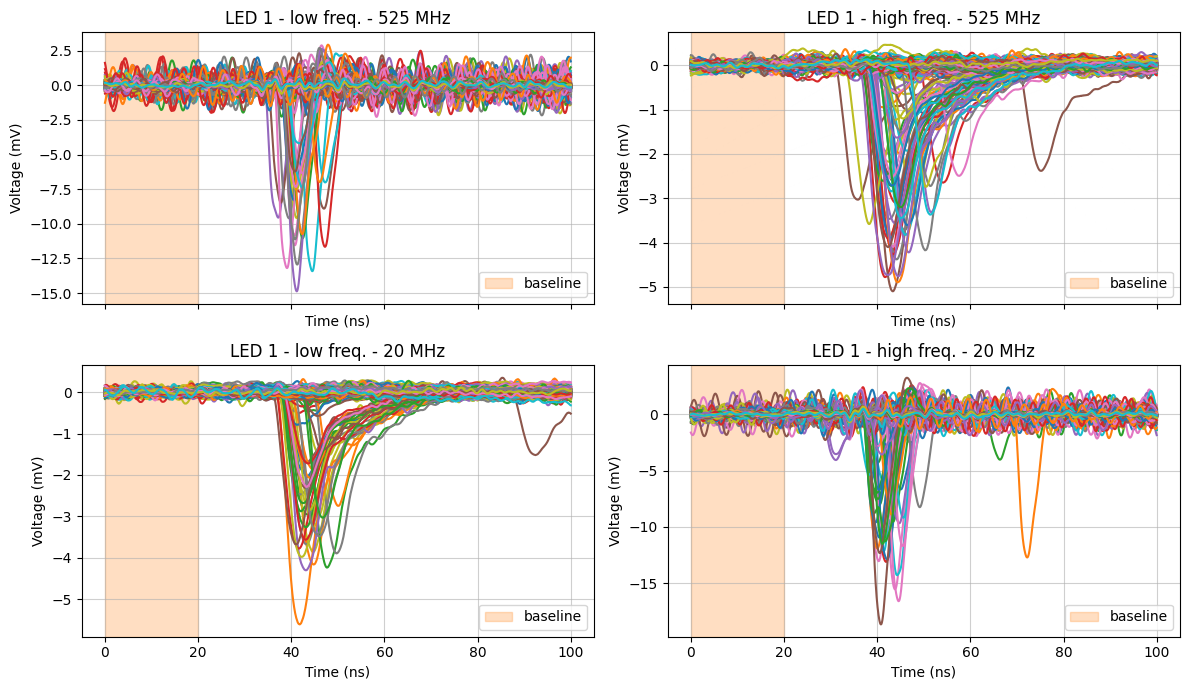

In [8]:
n_to_plot = 1000
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
i = 0
for k in plot_order:
    add_plot_waveforms(axes[i],data[k][0], data[k][1][:n_to_plot], title=data[k][3])
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
fig.tight_layout();
# save_plot(fig, save_plots, save_dir, "led0", f"waveforms",  Nevents=n_to_plot)



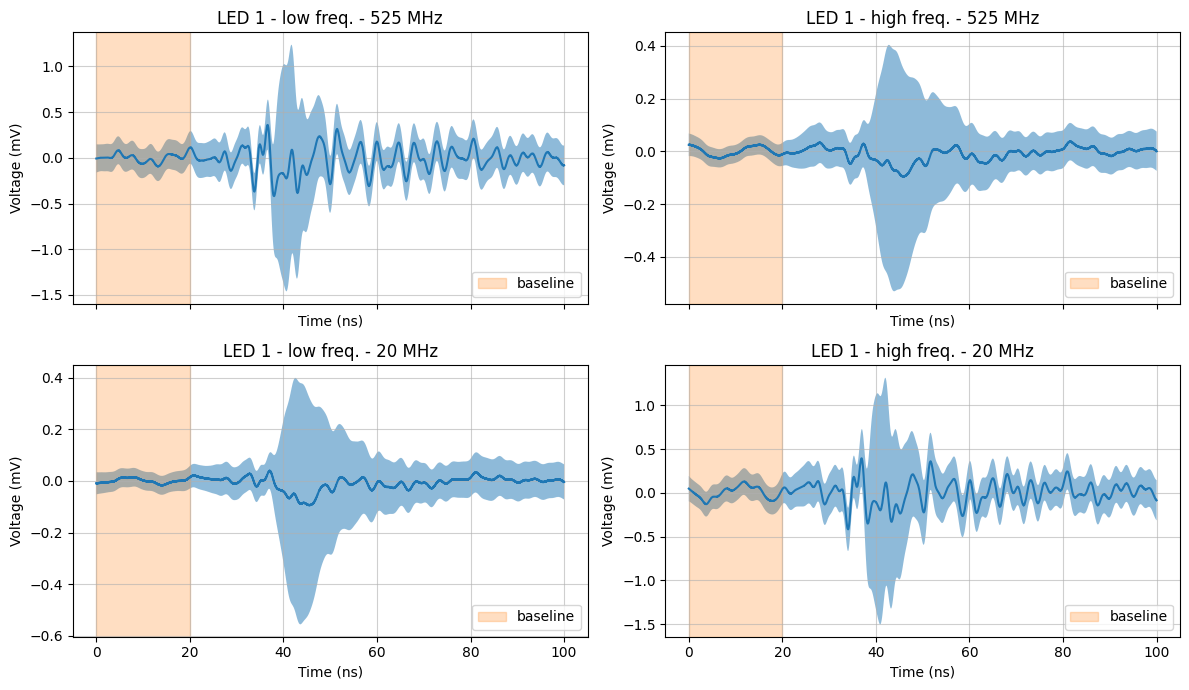

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
i = 0
for k in plot_order:
    add_mean_waveform(axes[i],data[k][0], data[k][1], title=data[k][3])
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
fig.tight_layout();

# save_plot(fig, save_plots, save_dir, "led0", f"avg",  Nevents=None)

# Focus on one thing

In [10]:
t = data['led1_low_525'][0]
waveform = data['led1_low_525'][1]
df = data['led1_low_525'][2]
title = data['led1_low_525'][3]

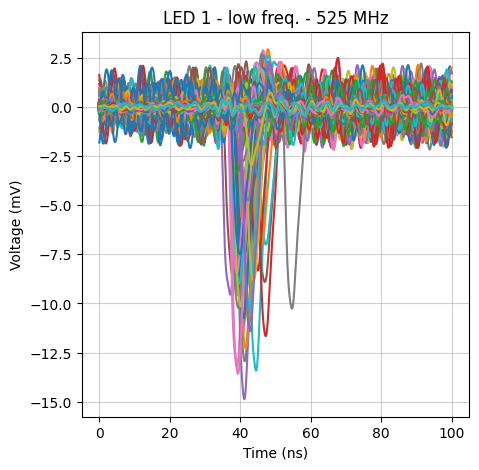

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True)
add_plot_waveforms(axes, t, waveform[:2000], title=title)

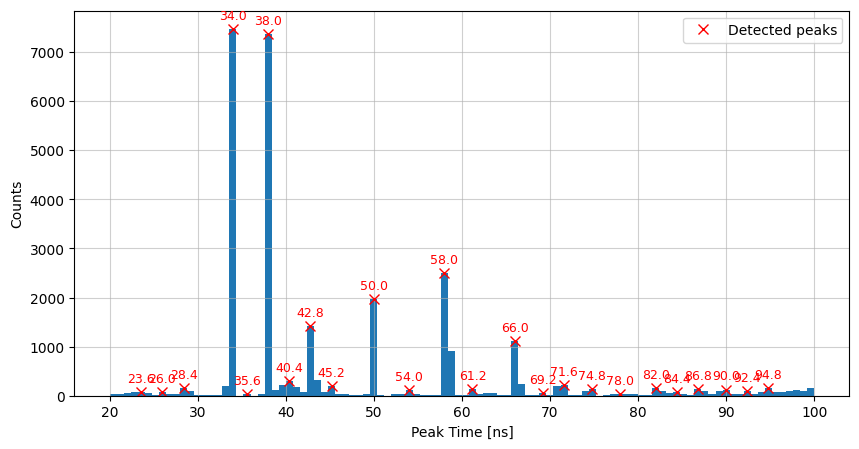

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

rg = (20, 100)

counts, edges, _ = axes.hist(df["peak_time_ns"], bins=100, range=rg, label="");
centers = 0.5 * (edges[:-1] + edges[1:])

peak_idx, properties = find_peaks(
    counts,
    prominence=20,    # adjust as needed
    distance=2,        # minimum number of bins between peaks
)
axes.plot( centers[peak_idx], counts[peak_idx], "rx", ms=7, mew=1, label="Detected peaks" )
for x, y in zip(centers[peak_idx], counts[peak_idx]):
    axes.text( x, y + 200, f"{x:.1f}", ha="center", color="red", fontsize=9, )

axes.legend(loc="upper right")
axes.set_xlabel("Peak Time [ns]")
axes.set_ylabel("Counts");

peak_times = centers[peak_idx]
time_differences = np.diff(peak_times)

In [13]:
df.columns

Index(['peak_idx', 'peak_time_ns', 'peak_amplitude_mV', 'area_mV_ns',
       'charge_peak_window_mV_ns', 'peak_width_ns', 'rise_time_10_90_ns',
       'fall_time_90_10_ns', 'cfd10_rise_ns', 'cfd20_rise_ns', 'cfd30_rise_ns',
       'cfd50_rise_ns', 'cfd90_rise_ns', 'cfd10_fall_ns', 'cfd20_fall_ns',
       'cfd30_fall_ns', 'cfd50_fall_ns', 'cfd90_fall_ns',
       'charge_cfd10_window_mV_ns', 'charge_cfd20_window_mV_ns',
       'charge_cfd30_window_mV_ns', 'charge_cfd50_window_mV_ns',
       'charge_cfd90_window_mV_ns', 'n_peaks', 'second_peak_time_ns',
       'second_peak_amplitude_mV', 'peak_separation_ns', 'baseline_mean_mV',
       'baseline_rms_mV', 'baseline_slope_mV_per_ns', 'event_file',
       'event_segment', 'snr'],
      dtype='str')

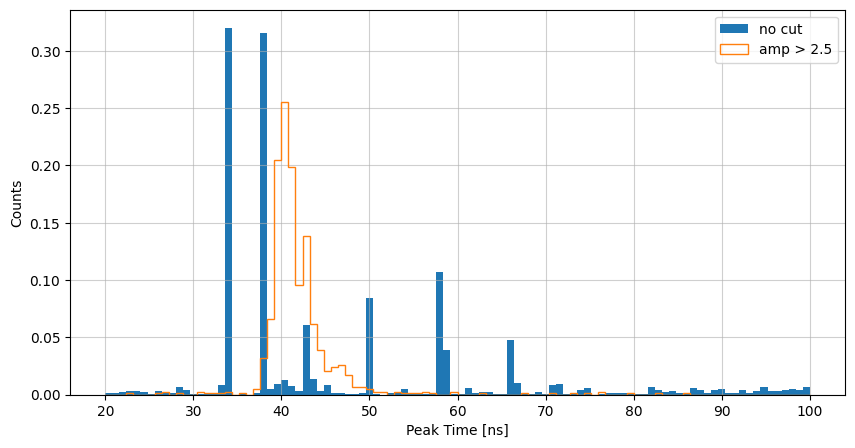

In [14]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

ampCut = 2.5

rg = (20, 100)

counts, edges, _ = axes.hist(df.peak_time_ns, bins=100, range=rg, label="no cut", density=True);
counts, edges, _ = axes.hist(df.query(f'peak_amplitude_mV > {ampCut}').peak_time_ns, bins=100, range=rg, label=f"amp > {ampCut}", density=True, histtype='step');
centers = 0.5 * (edges[:-1] + edges[1:])

# peak_idx, properties = find_peaks(
#     counts,
#     prominence=20,    # adjust as needed
#     distance=2,        # minimum number of bins between peaks
# )
# axes.plot( centers[peak_idx], counts[peak_idx], "rx", ms=7, mew=1, label="Detected peaks" )
# for x, y in zip(centers[peak_idx], counts[peak_idx]):
#     axes.text( x, y + 200, f"{x:.1f}", ha="center", color="red", fontsize=9, )

axes.legend(loc="upper right")
axes.set_xlabel("Peak Time [ns]")
axes.set_ylabel("Counts");

peak_times = centers[peak_idx]
time_differences = np.diff(peak_times)